

1.   Decide the N Clusters
2.   Initialize Centroids
3.   Assign Clusters (by calculating euclidean distance with each point)
4.   Move the Centroids
5.   Finish algorithim if there is no change in the cluster of the data points




https://medium.com/@tiami.abiola/clustering-wcss-and-elbow-method-427db8968ba1

https://medium.com/data-folks-indonesia/step-by-step-to-understanding-k-means-clustering-and-implementation-with-sklearn-b55803f519d6

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
import pandas as pd
import seaborn as sns

from mlxtend.plotting import plot_decision_regions

**Student Performance CSV**

In [ ]:
df = pd.read_csv("/content/student_clustering.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   cgpa    200 non-null    float64
 1   iq      200 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 3.2 KB


In [ ]:
df.shape

(200, 2)

<Axes: xlabel='cgpa', ylabel='iq'>

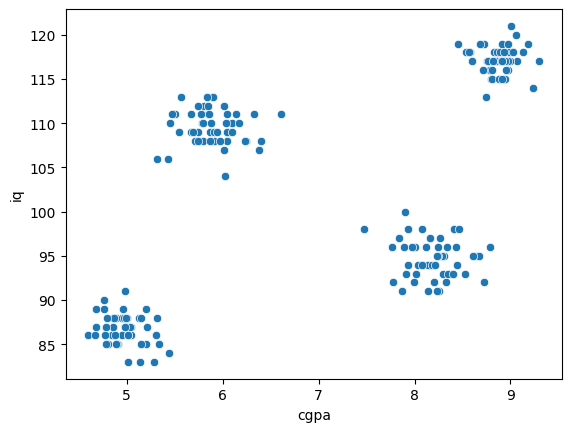

In [ ]:
sns.scatterplot(data = df, x = df["cgpa"], y = df["iq"])

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
wcss =[]

for i in range (1, 11):
  km = KMeans(n_clusters = i)
  km.fit_predict(df)
  wcss.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

In [ ]:
wcss

[29957.898287999997,
 4184.141269999999,
 2362.7133490000015,
 681.9696600000001,
 514.1616803171117,
 395.9605877691833,
 295.4391895943191,
 234.48687343199217,
 199.1703850136915,
 175.51731515251822]

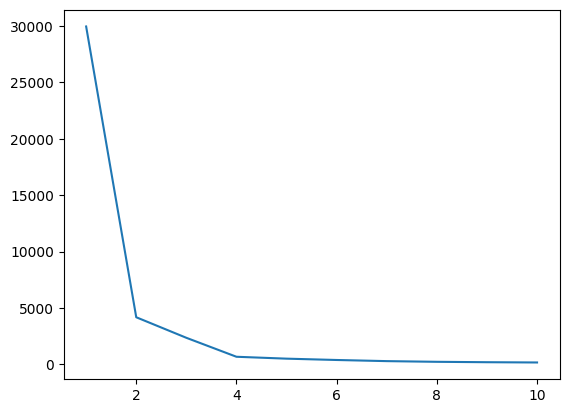

In [ ]:
plt.plot(range(1, 11), wcss)

In [ ]:
x = df.iloc[:, :].values
km = KMeans(n_clusters = 4)
ymeans = km.fit_predict(x)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
ymeans

array([0, 1, 2, 2, 1, 1, 2, 3, 1, 2, 0, 1, 2, 0, 1, 2, 1, 2, 1, 1, 2, 0,
       2, 0, 0, 2, 0, 3, 2, 1, 3, 1, 3, 1, 2, 2, 3, 1, 0, 1, 0, 2, 2, 0,
       3, 3, 2, 1, 3, 1, 0, 0, 3, 2, 3, 1, 1, 3, 1, 3, 1, 2, 2, 3, 0, 3,
       2, 0, 1, 2, 1, 3, 2, 0, 1, 3, 1, 3, 0, 2, 2, 3, 1, 0, 3, 0, 3, 1,
       3, 1, 3, 3, 2, 0, 2, 2, 3, 2, 0, 3, 1, 0, 0, 3, 0, 0, 2, 0, 3, 3,
       2, 3, 1, 1, 2, 3, 2, 1, 3, 0, 0, 1, 2, 3, 2, 0, 2, 1, 0, 2, 2, 1,
       0, 0, 1, 3, 1, 0, 2, 2, 2, 0, 1, 0, 0, 3, 0, 3, 1, 0, 3, 0, 3, 3,
       0, 2, 1, 3, 1, 2, 0, 3, 1, 2, 3, 0, 1, 0, 0, 3, 3, 1, 3, 0, 0, 2,
       3, 1, 0, 3, 3, 1, 1, 1, 2, 0, 2, 2, 3, 1, 2, 2, 0, 0, 2, 0, 3, 1,
       1, 3], dtype=int32)

In [ ]:
x[ymeans == 3,1]

array([115., 119., 117., 118., 118., 116., 116., 119., 116., 115., 115.,
       117., 118., 113., 116., 118., 117., 121., 116., 117., 117., 117.,
       114., 118., 118., 119., 118., 118., 117., 118., 117., 119., 118.,
       118., 117., 117., 117., 116., 118., 119., 117., 119., 120., 117.,
       115., 115., 117., 116., 118., 117.])

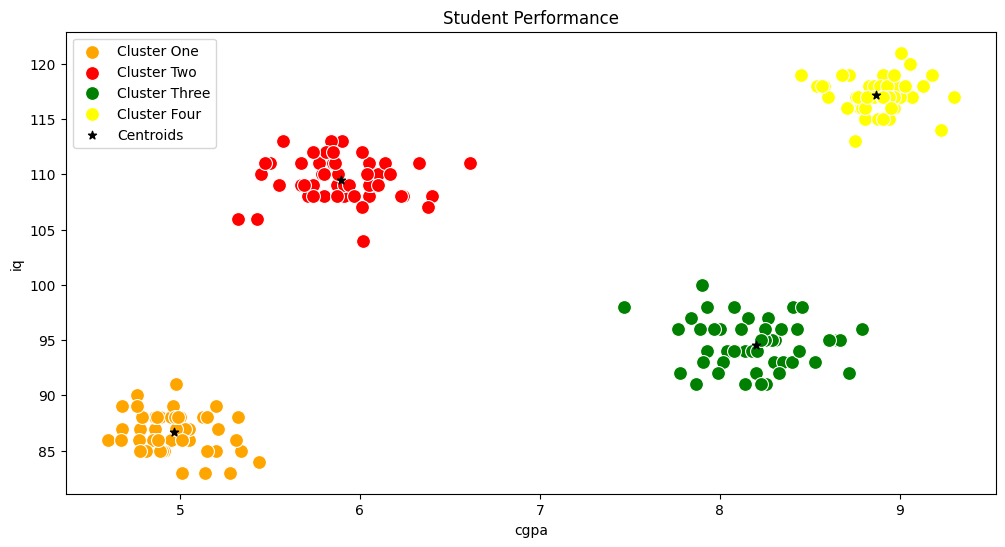

In [ ]:
plt.figure(figsize = (12, 6))

sns.scatterplot(x = x[ymeans == 0,0], y = x[ymeans == 0,1], color = "orange", label = "Cluster One", s = 100)
sns.scatterplot(x = x[ymeans == 1,0], y = x[ymeans == 1,1], color = "red", label = "Cluster Two", s = 100)
sns.scatterplot(x = x[ymeans == 2,0], y = x[ymeans == 2,1], color = "green", label = "Cluster Three", s = 100)
sns.scatterplot(x = x[ymeans == 3,0], y = x[ymeans == 3,1], color = "yellow", label = "Cluster Four", s = 100)

plt.scatter(x = km.cluster_centers_[:, 0], y = km.cluster_centers_[:, 1], color = "black", label = "Centroids", marker = "*")

plt.title("Student Performance")
plt.xlabel("cgpa")
plt.ylabel("iq")

plt.legend()
plt.show()

fit: returns the model instance itself. You would use it if you are interested in just training the model at that step.

fit_predict: returns the cluster labels for each sample in the data, providing a direct way to both train the model and get the clustering results in one step.

**Mall Customers**

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
x = df.iloc[:, 3:].values

In [ ]:
n_ = np.sqrt(len(x))

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

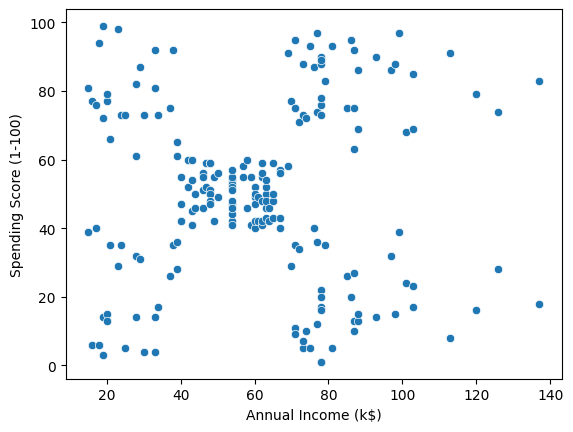

In [ ]:
sns.scatterplot(data = df, x = df["Annual Income (k$)"], y = df["Spending Score (1-100)"])

In [ ]:
wcss = []

for i in range(1, int(n_)):
  km = KMeans(n_clusters = i)
  km.fit_predict(x)
  wcss.append(km.inertia_)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` ex

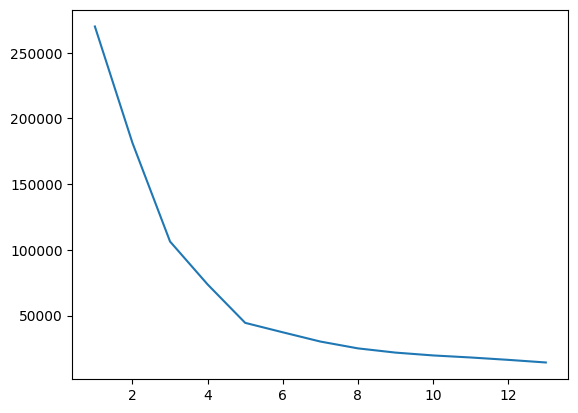

In [ ]:
plt.plot(range(1, int(n_)), wcss)

In [ ]:
km = KMeans(n_clusters = 5)
ymeans = km.fit_predict(x)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
ymeans

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

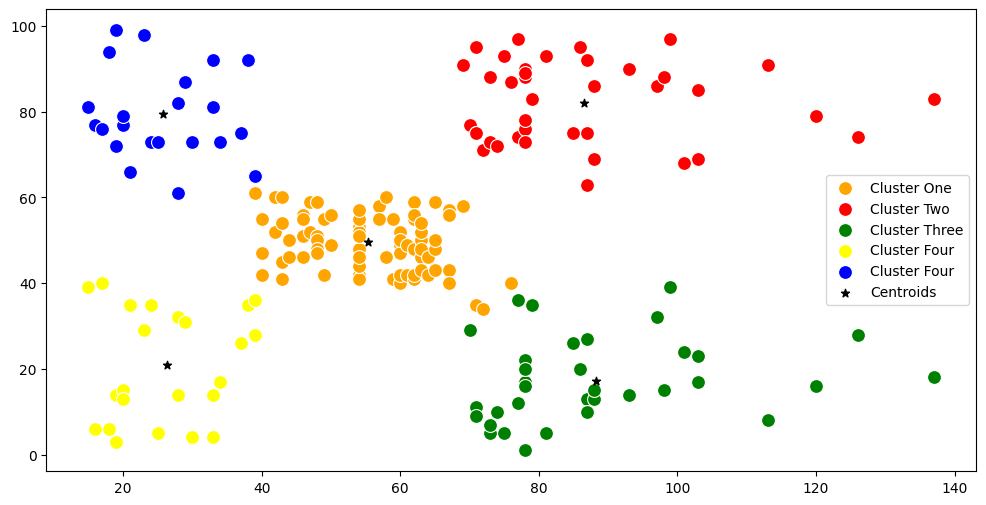

In [ ]:
plt.figure(figsize = (12, 6))

sns.scatterplot(x = x[ymeans == 0,0], y = x[ymeans == 0,1], color = "orange", label = "Cluster One", s = 100)
sns.scatterplot(x = x[ymeans == 1,0], y = x[ymeans == 1,1], color = "red", label = "Cluster Two", s = 100)
sns.scatterplot(x = x[ymeans == 2,0], y = x[ymeans == 2,1], color = "green", label = "Cluster Three", s = 100)
sns.scatterplot(x = x[ymeans == 3,0], y = x[ymeans == 3,1], color = "yellow", label = "Cluster Four", s = 100)
sns.scatterplot(x = x[ymeans == 4,0], y = x[ymeans == 4,1], color = "blue", label = "Cluster Four", s = 100)

plt.scatter(x = km.cluster_centers_[:, 0], y = km.cluster_centers_[:, 1], color = "black", label = "Centroids", marker = "*")

plt.legend()
plt.show()

**The silhouette score** measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). The score ranges from -1 to 1, where:

**1**.1 indicates that the data point is well clustered

**2**. 0 indicates that the data point is on or very close to the decision boundary between two neighboring clusters.

**3**. -1 indicates that the data point is misclassified.

In [ ]:
from sklearn.metrics import silhouette_score

**Titanic Dataset and Wine Dataset** for homework.

In [ ]:
labels = km.labels_

In [ ]:
labels

array([3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 0,
       3, 4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1], dtype=int32)

In [ ]:
score = silhouette_score(x, labels)

In [ ]:
print("the score of kmeans is: " + str(score))

the score of kmeans is: 0.553931997444648


In [34]:
df = pd.read_csv("/content/penguins_size.csv")
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [35]:
df = df[["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g", "species"]]
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
3,NaN,NaN,NaN,NaN,Adelie
4,36.7,19.3,193.0,3450.0,Adelie
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,Gentoo
340,46.8,14.3,215.0,4850.0,Gentoo
341,50.4,15.7,222.0,5750.0,Gentoo
342,45.2,14.8,212.0,5200.0,Gentoo


In [41]:
df = df.dropna()

In [42]:
x = df.iloc[:, :-1].values

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   species            342 non-null    object 
dtypes: float64(4), object(1)
memory usage: 16.0+ KB


In [44]:
x

array([[  39.1,   18.7,  181. , 3750. ],
       [  39.5,   17.4,  186. , 3800. ],
       [  40.3,   18. ,  195. , 3250. ],
       ...,
       [  50.4,   15.7,  222. , 5750. ],
       [  45.2,   14.8,  212. , 5200. ],
       [  49.9,   16.1,  213. , 5400. ]])

In [45]:
km = KMeans(n_clusters = 3, random_state = 0).fit(x)
ymeans = km.predict(x)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [46]:
ymeans

array([1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1,
       2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1,
       2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1,
       2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2,
       0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 1, 0, 2, 2, 0,
       2, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0,

In [47]:
df["clusters"] = ymeans

<ipython-input-47-8418e0584276>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["clusters"] = ymeans


In [48]:
df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,species,clusters
0,39.1,18.7,181.0,3750.0,Adelie,1
1,39.5,17.4,186.0,3800.0,Adelie,1
2,40.3,18.0,195.0,3250.0,Adelie,1
4,36.7,19.3,193.0,3450.0,Adelie,1
5,39.3,20.6,190.0,3650.0,Adelie,1
...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,Gentoo,2
340,46.8,14.3,215.0,4850.0,Gentoo,2
341,50.4,15.7,222.0,5750.0,Gentoo,0
342,45.2,14.8,212.0,5200.0,Gentoo,0


In [49]:
centroids = km.cluster_centers_

In [56]:
feature_names = ["culmen_length_mm", "culmen_depth_mm", "flipper_length_mm", "body_mass_g"]

In [57]:
centroids_df = pd.DataFrame(centroids, columns = feature_names)

In [58]:
centroids_df

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
0,49.050000,15.566176,220.764706,5449.632353
1,41.284706,18.057647,190.317647,3532.352941
2,44.879808,16.705769,205.259615,4480.048077


In [66]:
fig = px.scatter_3d(df, x = feature_names[0], y = feature_names[1], z = feature_names[2], color = "clusters",
                    title = "3D data plot of Penguins Cluster", labels = {feature_names[0]:feature_names[0], feature_names[1]:feature_names[1], feature_names[2]:feature_names[2]})

fig.add_scatter3d(x = centroids_df[feature_names[0]], y = centroids_df[feature_names[1]], z = centroids_df[feature_names[2]])

fig.show()

In [67]:
fig = px.scatter_3d(df, x = feature_names[1], y = feature_names[2], z = feature_names[3], color = "clusters",
                    title = "3D data plot of Penguins Cluster", labels = {feature_names[0]:feature_names[0], feature_names[1]:feature_names[1], feature_names[2]:feature_names[2]})

fig.add_scatter3d(x = centroids_df[feature_names[1]], y = centroids_df[feature_names[2]], z = centroids_df[feature_names[3]])

fig.show()

In [68]:
fig = px.scatter_3d(df, x = feature_names[0], y = feature_names[1], z = feature_names[3], color = "clusters",
                    title = "3D data plot of Penguins Cluster", labels = {feature_names[0]:feature_names[0], feature_names[1]:feature_names[1], feature_names[2]:feature_names[2]})

fig.add_scatter3d(x = centroids_df[feature_names[0]], y = centroids_df[feature_names[1]], z = centroids_df[feature_names[3]])

fig.show()

In [65]:
fig = px.scatter_3d(df, x = feature_names[0], y = feature_names[2], z = feature_names[3], color = "clusters",
                    title = "3D data plot of Penguins Cluster", labels = {feature_names[0]:feature_names[0], feature_names[1]:feature_names[1], feature_names[2]:feature_names[2]})

fig.add_scatter3d(x = centroids_df[feature_names[0]], y = centroids_df[feature_names[2]], z = centroids_df[feature_names[3]])

fig.show()